In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from matplotlib import patches

from advection_diffusion_utils import *

torch.manual_seed(67)

In [2]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        if self.activation == 'tanh':
            self.act = nn.Tanh()
        elif self.activation == 'relu':
            self.act = nn.ReLU()
        elif self.activation == 'gelu':
            self.act = nn.GELU()
        elif self.activation == 'sin':
            self.act = torch.sin  
        else:
            raise ValueError(f"Unknown activation: {activation}")
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer(a)
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                if self.activation == 'sin':
                    nn.init.xavier_uniform_(m.weight)
                else:
                    g = nn.init.calculate_gain(self.activation)
                    torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

210

In [3]:
BATCH_SIZE = 32
EPOCHS  = 50

In [4]:
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 1000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 500)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

In [5]:
def f(x):
    # return torch.sin(5*x) + torch.tan(10*x)
    return torch.sin(x)# + torch.tan(10*x)

def g(x):
    return torch.sin(0.1*x)

domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]

def get_initial(data, domain, f):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:, 0]
    u = f(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)

    return data, u


def get_BC(data, domain, g):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    t = data[:, 1]

    # x = 0
    data_0 = data.clone()
    data_0[:, 0] = domain[0][0]
    u_0_g = g(t)

    # x = L
    data_L = data.clone()
    data_L[:, 0] = domain[0][1]
    u_L_g = g(t)

    return data_0, data_L, u_0_g, u_L_g

def get_interior(data, domain): # returns x (location)
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

# get_BC(next(iter(train_dataloader)), g)

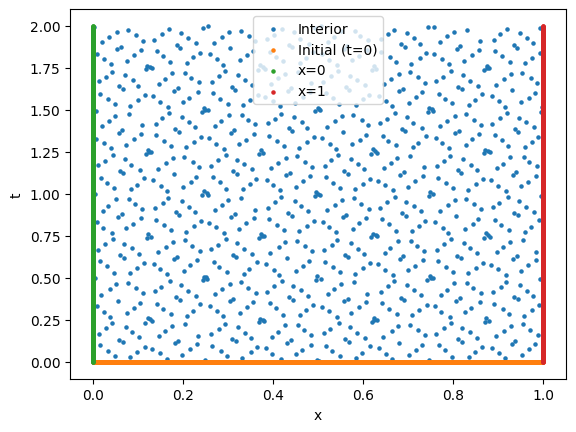

In [6]:
dummy_data = []

for d in train_dataloader:
    dummy_data.append(d)
    
data = torch.cat(dummy_data, dim = 0)

interior = get_interior(data, domain)
data_ic, ic = get_initial(data, domain, f)
bc_0, bc_L, u_0, u_L = get_BC(data, domain, g)

plt.figure()
plt.scatter(interior[:,0], interior[:,1], s=5, label="Interior")
plt.scatter(data_ic[:,0], data_ic[:,1], s=5, label="Initial (t=0)")

plt.scatter(bc_0[:,0], bc_0[:,1], s=5, label="x=0")
plt.scatter(bc_L[:,0], bc_L[:,1], s=5, label="x=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("t")
plt.show()

In [7]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20)

def get_interior_residual(u_model, points, a, epsilon):
    # points = points.clone().detach().requires_grad_(True)
    points.requires_grad_(True)
    u = u_model(points)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph = True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    u_xx = torch.autograd.grad(u_x.sum(), points, create_graph=True)[0][:, 0]

    interior_residual = u_t + (a * u_x) - (epsilon * u_xx)

    return interior_residual.unsqueeze(1)

interior_data = get_interior(next(iter(train_dataloader)), domain)
get_interior_residual(u_predictor_model, interior_data, 1, 0).shape

torch.Size([32, 1])

In [8]:
def get_IC_residue(u_model, points):
    data, u_true = points
    u_pred = u_model(data)
    
    return u_pred - u_true[:, 0].unsqueeze(1)

IC_data, IC_data_u = get_initial(next(iter(train_dataloader)), domain, f) # u, u_t (exact at t = 0)
get_IC_residue(u_predictor_model, (IC_data, IC_data_u)).shape


torch.Size([32, 1])

In [9]:
def get_BC_residue(u_model, points):
    data_0, data_L, u_0_g, u_L_g = points

    res_0 = u_model(data_0) - u_0_g.unsqueeze(1)
    res_L = u_model(data_L) - u_L_g.unsqueeze(1)

    return res_0, res_L

BC_data = get_BC(next(iter(train_dataloader)), domain, g) 
get_BC_residue(u_predictor_model, BC_data)[0].shape

torch.Size([32, 1])

In [10]:
def get_flat_grad(output, model):
    grads = torch.autograd.grad(output, model.parameters(), retain_graph=True, create_graph=False, allow_unused=True )
    return torch.cat([
        (g if g is not None else torch.zeros_like(p)).reshape(-1)
        for g, p in zip(grads, model.parameters())
    ])
    

grads = get_flat_grad(u_predictor_model(torch.rand(32,2)).sum(), u_predictor_model)
grads.shape

torch.Size([1761])

In [11]:
def compute_ntk(model, inputs, residual_fn):
    grads = []

    for i in range(inputs.shape[0]):
        model.zero_grad()

        x = inputs[i:i+1]
        r = residual_fn(model, x)  # shape [1,1]

        g = get_flat_grad(r, model).detach()
        grads.append(g)

    G = torch.stack(grads)   # [N, P]

    K = G @ G.T              # [N, N]

    return K

def get_eigenvalues(K):
    eigvals = torch.linalg.eigvals(K).real
    eigvals = torch.sort(eigvals, descending=True).values
    return eigvals


K_pde = compute_ntk(
    u_predictor_model,
    interior_data[:100],   
    lambda m, x: get_interior_residual(m, x, a=0.1, epsilon=0)
)

K_ic = compute_ntk(
    u_predictor_model,
    IC_data[:100],
    lambda m, x: m(x)
)

K_bc = compute_ntk(
    u_predictor_model,
    BC_data[0][:100],   
    lambda m, x: m(x)
)

eig_pde = get_eigenvalues(K_pde)
eig_ic = get_eigenvalues(K_ic)
eig_bc = get_eigenvalues(K_bc)

eig_bc.shape

torch.Size([32])

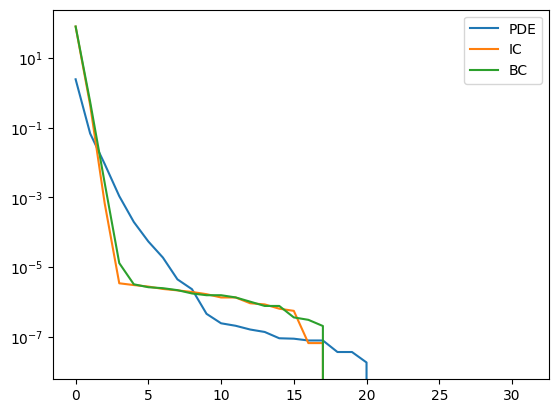

In [12]:
plt.semilogy(eig_pde.numpy(), label="PDE")
plt.semilogy(eig_ic.numpy(), label="IC")
plt.semilogy(eig_bc.numpy(), label="BC")
plt.legend()

In [13]:
def grad_norm(loss, models):
    if not isinstance(models, list):
        models = [models]

    params = []
    for m in models:
        params += list(m.parameters())

    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        allow_unused=True
    )

    norm = 0.0
    for g in grads:
        if g is not None:
            norm += torch.sum(g**2)
    return torch.sqrt(norm)

In [14]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 8, neurons = 128)

lr = 1e-4
optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()),
    lr=lr
)

a = 10
epsilon = 0

w_g_epoch_loss_track, w_g_epoch_loss_track_test, w_g_residue_tracker, w_g_grad_tracker, w_g_lambda_tracker = train(
                                                                                           epochs = 100, optimizer = optimizer, 
                                                                                           u_predictor_model = u_predictor_model, 
                                                                                           train_dataloader = train_dataloader, test_dataloader = test_dataloader, 
                                                                                           get_interior = get_interior, get_initial = get_initial, get_BC = get_BC,
                                                                                           get_interior_residual = get_interior_residual, get_IC_residue = get_IC_residue, get_BC_residue = get_BC_residue, 
                                                                                           domain = domain,
                                                                                           g = g, f = f, 
                                                                                           alpha = a, epsilon = epsilon,
                                                                                           lr_annealing_decay = True,
                                                                                           initial_lr = lr,
                                                                                           lambda_scaling = True
                                                                                           )

EPOCH: 1 | train loss: 0.1878 | test loss: 0.1461
EPOCH: 11 | train loss: 0.0469 | test loss: 0.0416
EPOCH: 21 | train loss: 0.0239 | test loss: 0.0314
EPOCH: 31 | train loss: 0.0165 | test loss: 0.0160
EPOCH: 41 | train loss: 0.0166 | test loss: 0.0162
EPOCH: 51 | train loss: 0.0153 | test loss: 0.0157
EPOCH: 61 | train loss: 0.0150 | test loss: 0.0152
EPOCH: 71 | train loss: 0.0149 | test loss: 0.0156
EPOCH: 81 | train loss: 0.0147 | test loss: 0.0146
EPOCH: 91 | train loss: 0.0147 | test loss: 0.0147
EPOCH: 100 | train loss: 0.0148 | test loss: 0.0145


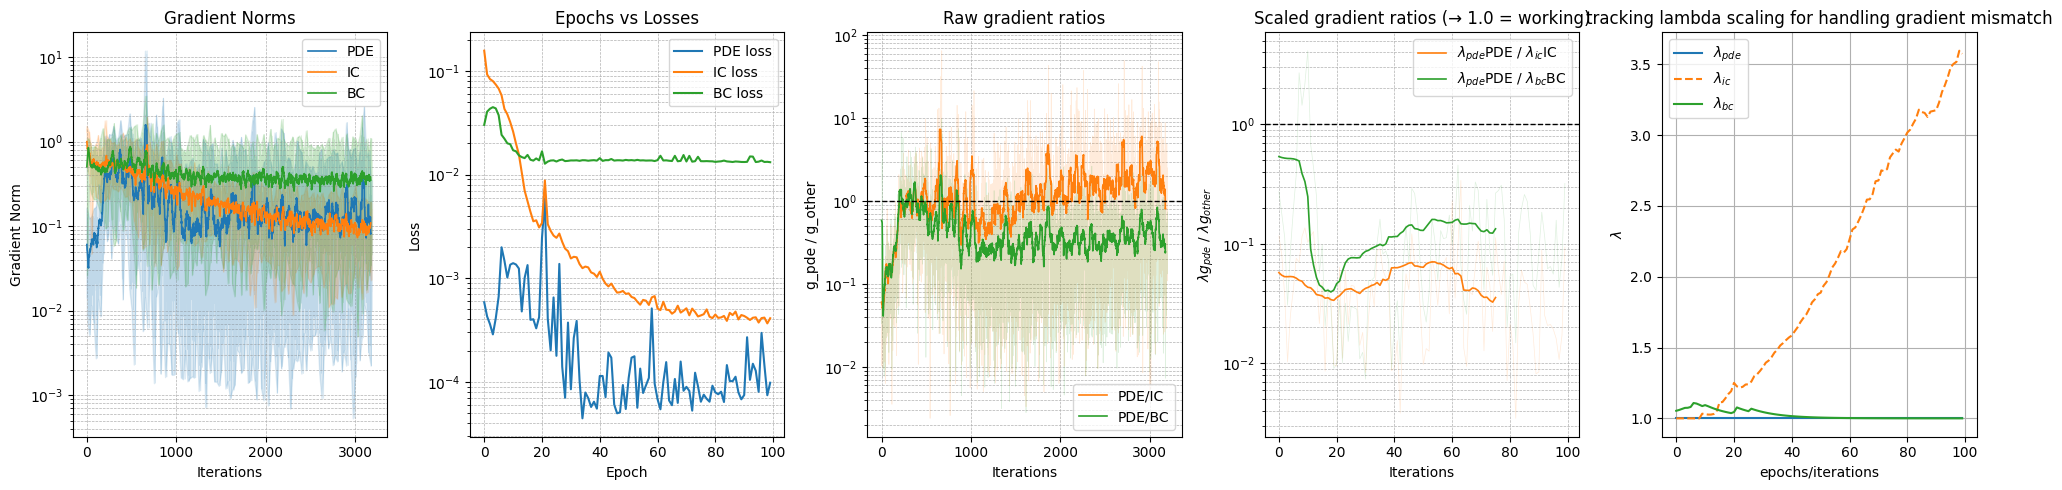

In [15]:
plot_gradients_and_losses(w_g_grad_tracker, w_g_residue_tracker, w_g_lambda_tracker, window=25)

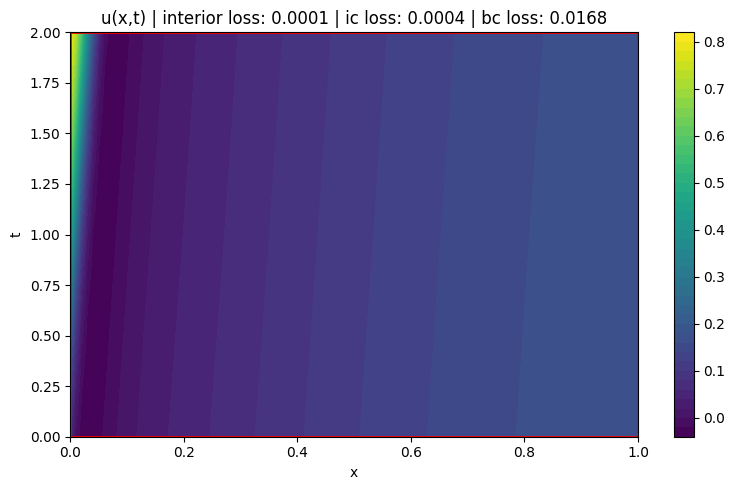

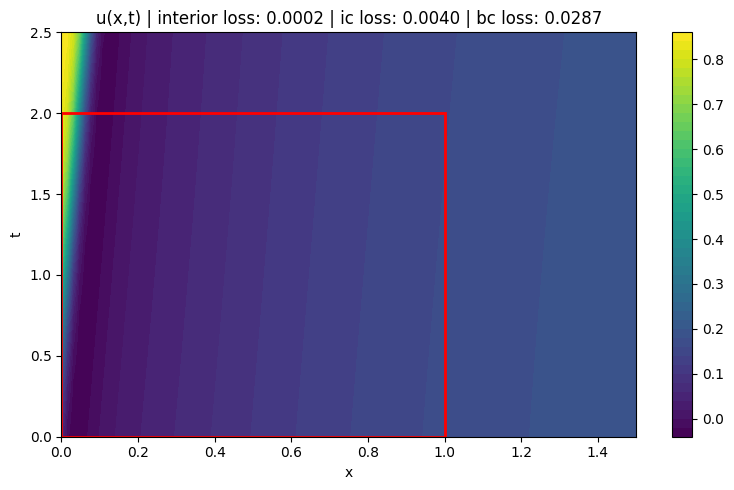

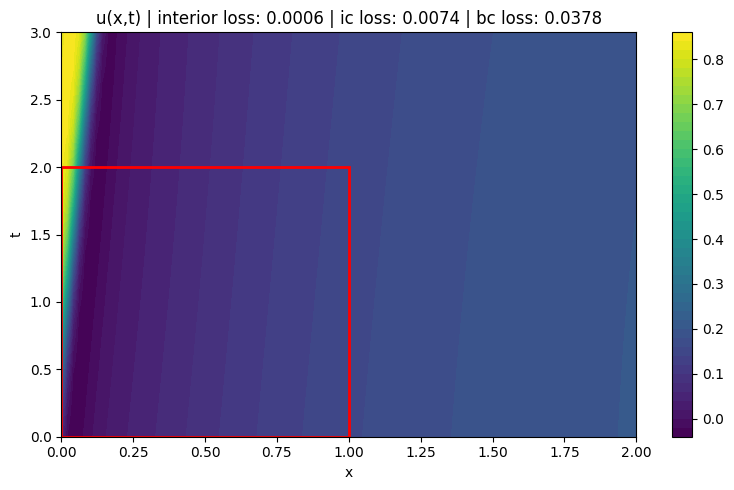

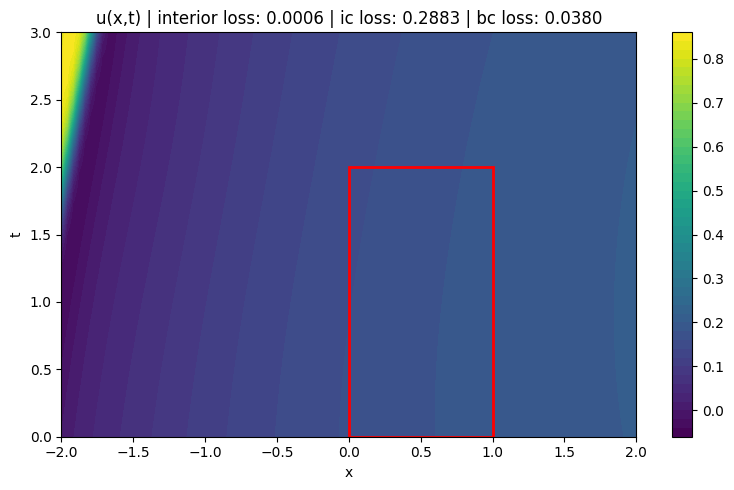

In [ ]:
inference(domain = domain, 
          u_model = u_predictor_model, 
          f = f, g = g, 
          a = a, 
          epsilon = epsilon)

inference(domain = torch.tensor([[0, 1.5], [0, 2.5]]), 
          u_model = u_predictor_model, 
          f = f, g = g, 
          a = a, 
          epsilon = epsilon)

inference(domain = torch.tensor([[0, 2], [0, 3]]), 
          u_model = u_predictor_model, 
          f = f, g = g, 
          a = a, 
          epsilon = epsilon)

inference(domain = torch.tensor([[-2, 2], [0, 3]]), 
          u_model = u_predictor_model, 
          f = f, g = g, 
          a = a, 
          epsilon = epsilon)

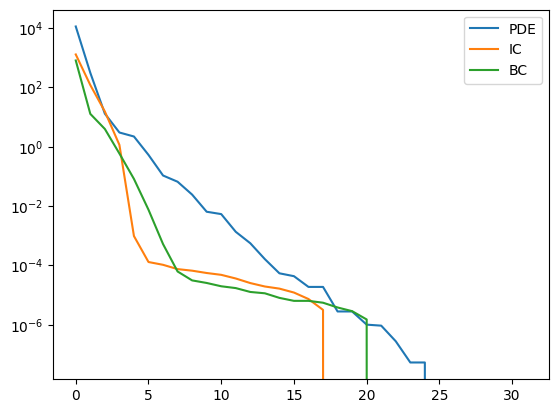

In [18]:

K_pde = compute_ntk(
    u_predictor_model,
    interior_data[:100],   
    lambda m, x: get_interior_residual(m, x, a=0.1, epsilon=0)
)

K_ic = compute_ntk(
    u_predictor_model,
    IC_data[:100],
    lambda m, x: m(x)
)

K_bc = compute_ntk(
    u_predictor_model,
    BC_data[0][:100],   
    lambda m, x: m(x)
)

eig_pde = get_eigenvalues(K_pde)
eig_ic = get_eigenvalues(K_ic)
eig_bc = get_eigenvalues(K_bc)

plt.semilogy(eig_pde.numpy(), label="PDE")
plt.semilogy(eig_ic.numpy(), label="IC")
plt.semilogy(eig_bc.numpy(), label="BC")
plt.legend()